# **Classification Project**
## **Projekt no.2,  ZSU, MUSIL JURAJ, MUS0160**

# **Zdrojové dáta a ich základná kontrola a úprava**
Cieľom predkladaného projektu je "klasifikačná" analýza zvoleného datasetu. Z datasetov, ktoré sú v rámci zadania tohto projektu k dispozícii som si zvolil dataset "Credit Card Customers Churn Prediction".

Dataset obsahuje rôzne informácie o  zákazníkoch banky využívajúcich kreditné karty a jeden kľúčový cieľový atribút Attrition_Flag vyjadrujúci skutočnosť či zákazník banku opustil (Attrited Customer) alebo ostáva naďalej jej zákazníkom (Existing Customer).

Klasifikačná analýza je realizovaná s cieľom predikovať (na základe ostatných dostupných atribútov) či zákazník banku opustí alebo ostane jej zákazníkom.
Dataset obsahuje viac ako 10 000 záznamov a zastúpenie hodnôt (Attrited customer) a (Existing customer) je vysoko nevyvážené (v prospech Existing Customer).

Dataset je teda vhodný na klasifikačný problém, keďže hlavným cieľom banky je identifikovať zákazníkov s vysokým rizikom odchodu, na ktorých sa následne banka môže zamerať s nadštandardnými ponukami.

Dataset som stiahol zo stránky projektu a sprístupnil ho na účte na github-e:
https://raw.githubusercontent.com/Musiljuraj/MUS0160_ZSU_Project02/refs/heads/main/BankChurners.csv

V nasledujúcej bunke sú importované všetky potrebné knižnice a rovnako je nahratý aj uvedený dataset.





In [1]:
#libraries import
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier #tried and due to non-convergence problems not used in final version
from sklearn.naive_bayes import GaussianNB #alternative to MPL

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

#ensuring randomness is in fact "deterministic in one run"
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

#Credit Card Customers Churn Prediction - dataset
url_dataset = 'https://raw.githubusercontent.com/Musiljuraj/MUS0160_ZSU_Project02/refs/heads/main/BankChurners.csv'

df = pd.read_csv(url_dataset)



Nasleduje bežná kontrola veľkosti datasetu a úvodná vizuálna inšpekcia hodnôt v ňom uložených.
Zo zobrazených hodnôt je zrejmé, že dataset obsahuje mix číselných a kategoriálnych premenných, pričom číselné premenné majú veľmi rozdielne škály.

In [2]:
print("Shape:", df.shape)
display(df.head(100))

Shape: (10127, 23)


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.999910
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.999940
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.999980
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.999870
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.999980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,719712633,Existing Customer,64,M,1,Graduate,Married,Less than $40K,Blue,52,...,1709.0,895,814.0,1.656,1673,32,0.882,0.524,0.000343,0.999660
96,772629333,Existing Customer,45,M,3,Graduate,Married,$40K - $60K,Blue,35,...,3454.0,1200,2254.0,0.597,1313,30,0.304,0.347,0.000226,0.999770
97,720336708,Existing Customer,53,M,3,Doctorate,Married,$40K - $60K,Blue,35,...,3789.0,1706,2083.0,1.047,1609,42,0.680,0.450,0.000270,0.999730
98,802013583,Existing Customer,56,M,3,College,Married,$120K +,Blue,50,...,9689.0,2250,7439.0,0.576,1158,19,0.727,0.232,0.000042,0.999960


V nasledovnej časti prevádzam (encode) cieľový atribút Attrition_Flag do binárnej podoby (1 - Attrited customer, zákazník ktorý banku opustil, 0 - Existing customer, zostávajúci zákazník).

Takéto binárne kódovanie je vhodné pre štandardné metódy binárnej klasifikácie a zároveň vhodne definuje kľúčovú cieľovú triedu (attrition, odchod zákazníka) pre účely neskôr zvolenej kľúčovej metriky (recall).

V tomto bloku rovnako odtsraňujem stĺpec CLIENTNUM, keďže ide o jednoznačný identifikátor klientov, ktorý sa v datasete neopakuje (a pre účely klasifikácie nie je teda významný). Rovnako (v zmysle poznámky v zadaní) odstraňujem posledné dva stĺpce (Naive_Bayes_Classifiers).

Pre účely vlastnej k-fold klasifikácie rozdeľujem dataset na vstupné dáta - X a cieľovú premennú - Y (obsahuje len hodnoty Attrition_Flag).

Kontrolou bolo zistené, že dataset neobsahuje žiadne duplicitné ani chýbajúce hodnoty.


In [3]:
print("\nColumns:")
print(df.columns.tolist())

#Define and encode target variable
df["Attrition_Flag"] = df["Attrition_Flag"].map({
    "Existing Customer": 0,
    "Attrited Customer": 1
})

#Droppin uneccesary columns - CLIENTNUM and "Naive Bayes" columns
df = df.drop(columns= [   "CLIENTNUM",
                          "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1",
                          "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2"
                      ])

#Define input features and target variables
X = df.drop(columns=["Attrition_Flag"])
Y = df["Attrition_Flag"]

print("\nFinal dataset for modeling:")
print("X shape:", X.shape)
print("Y shape:", Y.shape)

#Checking for missing values:
print("\nMissing values in dataset:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())


Columns:
['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']

Final dataset for modeling:
X shape: (10127, 19)
Y shape: (10127,)

Missing values in dataset: 0
Duplicate rows: 0


# **Exploratory data analysis**
Dataset je tvorený numerickými a kategorickými atribútmi. Cieľový atribút je Attrition_Flag, v tejto etape už transformovaný na binárny kód 0 (Existing Customer), 1 (Attrited Customer).

Kategorické atribúty (stĺpce):Gender, Education_Level, Marital_Status, Income_Category, Card_Category

Tieto atribúty budú neskôr transformované do numerickej podoby s využitím one-hot encoding (keďže hodnoty nie je možné vhodne usporiadať).

Numerické atribúty: všetky zvyšné stĺpce, zahŕňajú demografické atribúty (Customer_Age, Dependent_Count), "relationship" atribúty (Months_On_Book, Total_Relationship_Count), finančné/transakčné atribúty (Credit_Limit, Total_Trans_Amt, Avg_Utilization_Ratio ..).

S ohľadom na skutočnosť, že tieto atribúty obsahujú hodnoty vo veľmi rozdielnych mierkach, budú v neskoršej etape (preprocessing) škálované (scaled), keďže niektoré z použitých algoritmov sú citlivé voči veľkým rozdielom v škále číslených hodnôt (predovšetkým k=NN).

In [4]:
#Getting to know which datatypes there are
print("\nColumn data types:")
display(df.dtypes.to_frame(name="dtype"))

print("\nNumber of numeric and categorical features:")
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
print("Numeric features:", len(num_cols))
print("Categorical features:", len(cat_cols))
print("\nCategorical columns:", cat_cols)


Column data types:


,dtype
Attrition_Flag,int64
Customer_Age,int64
Gender,object
Dependent_count,int64
Education_Level,object
Marital_Status,object
Income_Category,object
Card_Category,object
Months_on_book,int64
Total_Relationship_Count,int64



Number of numeric and categorical features:
Numeric features: 15
Categorical features: 5

Categorical columns: ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']


Cieľový atribút (Attrition_Flag) je výrazne nevyvážený (cca 80% hodnôt 0 a cca 20% hodnôt 1).

Uvedená skutočnosť je jedným z dôvodov, prečo v ďalšej etape ako kľúčovú metriku volím "Recall". Samotná metrika "Accuracy" (presnosť) totiž môže byť zavádzajúca, keďže aj triviálny klasifikátor, ktorý by vždy predikoval iba väčšinovú triedu, by už dosiahol približne 84 % presnosť.
Druhým dôvodom je skutočnosť, že kľúčovou kategóriou na ktorú sa chce banka v tejto analýze zamieravať je práve "Recall", t.j. klienti, ktorý podľa predikcie banku plánujú opustiť. Ak model nedokáže identifikovať zákazníka, ktorý sa chystá odísť (false negative), môže to viesť k priamej strate príjmov a k premárnenej príležitosti na včasné protiopatrenia. Naopak, ak model nesprávne označí zákazníka, ktorý v skutočnosti neodíde, ako attrition (false positive), zvyčajne to spôsobí len relatívne malý náklad, napríklad v podobe zbytočnej ponuky na udržanie zákazníka.
Ako podporné metriky budú vyhodnocované aj "Precision" a "F1-score".



===== Target Distribution =====
Counts:
 Attrition_Flag
0    8500
1    1627
Name: count, dtype: int64

Ratios:
 Attrition_Flag
0    0.83934
1    0.16066
Name: proportion, dtype: float64


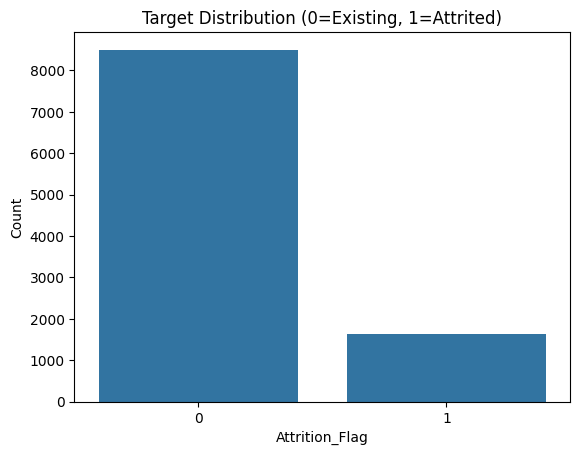

In [5]:
print("\n===== Target Distribution =====")
target_counts = df["Attrition_Flag"].value_counts()
target_ratio = df["Attrition_Flag"].value_counts(normalize=True)

print("Counts:\n", target_counts)
print("\nRatios:\n", target_ratio)

plt.figure()
sns.countplot(x="Attrition_Flag", data=df)
plt.title("Target Distribution (0=Existing, 1=Attrited)")
plt.xlabel("Attrition_Flag")
plt.ylabel("Count")
plt.show()


V nasledujúcom bloku analyzujem základné štatistické charakteristiky numerických atribútov. Výstupné hodnoty potvrdzujú pomerne široký rozptyl numerických hodnôt a potvrdzujú teda aj potrebu numerického škálovania (s ohľadom na nižšie uvedenú voľbu algoritmov - k-NN, Naive Bayes a Desicion Trees je škálovanie absolútne nevyhnutné predovšetkým pre k-NN a čiastočne pre Naive Bayes, keďže ale škálovanie nezhoršuje kvalitu klasifikácie pre Decision Tree, rozhodol som sa v záujme jednoduchosti kódu zvoliť jednotný preprocessing so škálovaním pre všetky tri algoritmy).


===== Numeric Feature Descriptive Statistics =====


,Attrition_Flag,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,0.160660,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,0.367235,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,0.000000,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,0.000000,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,0.000000,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,0.000000,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,1.000000,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000



===== Distributions for Key Numeric Features =====


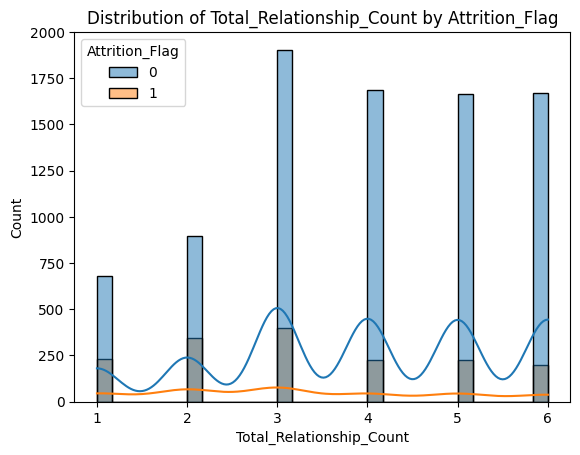

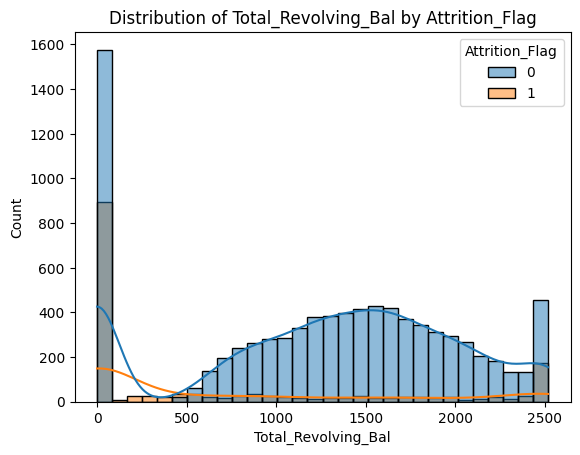

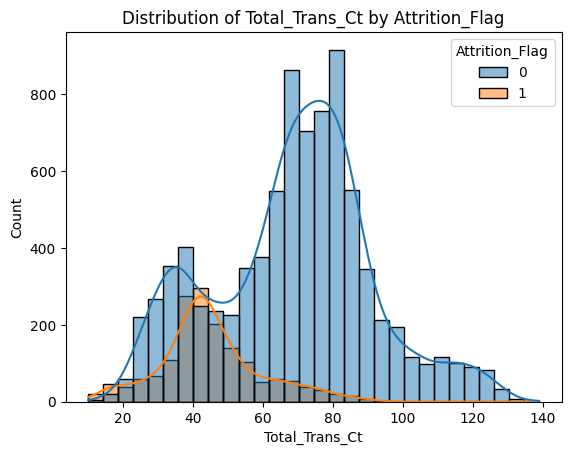

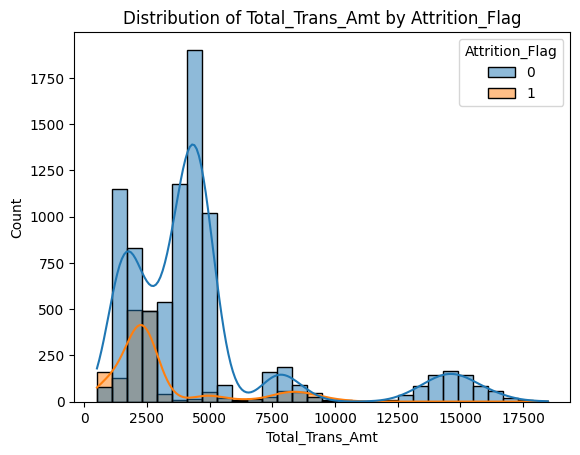

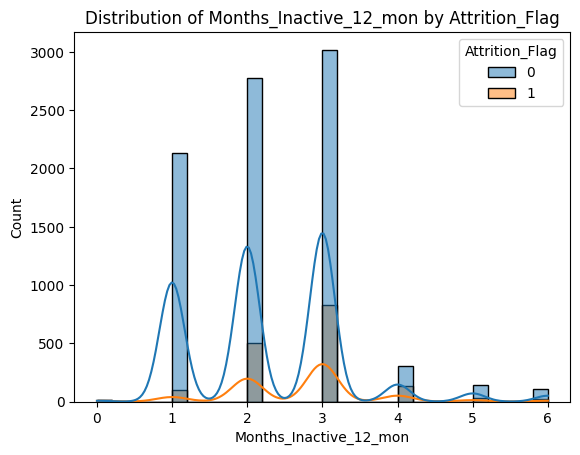

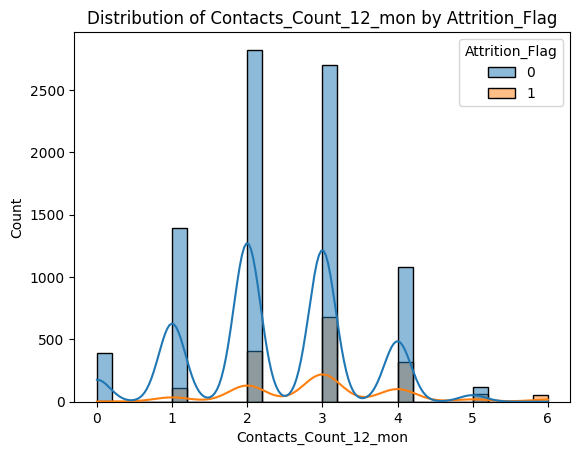

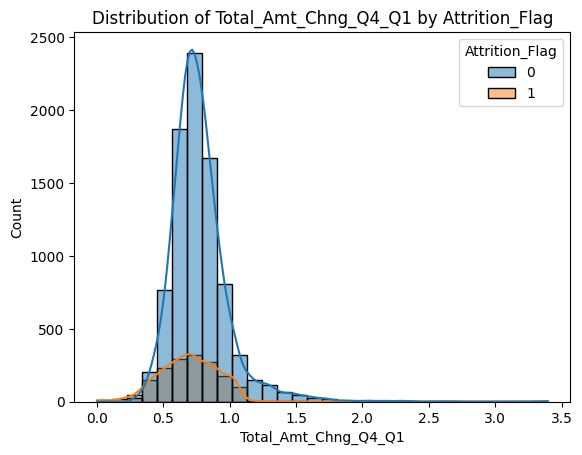

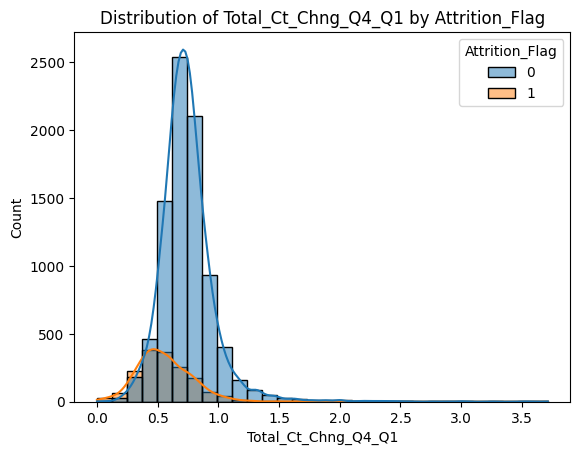

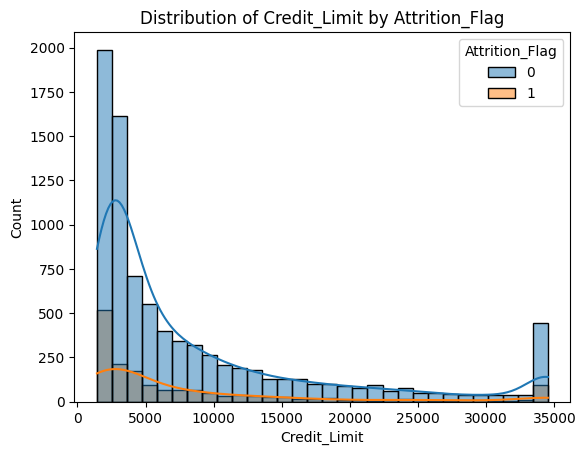

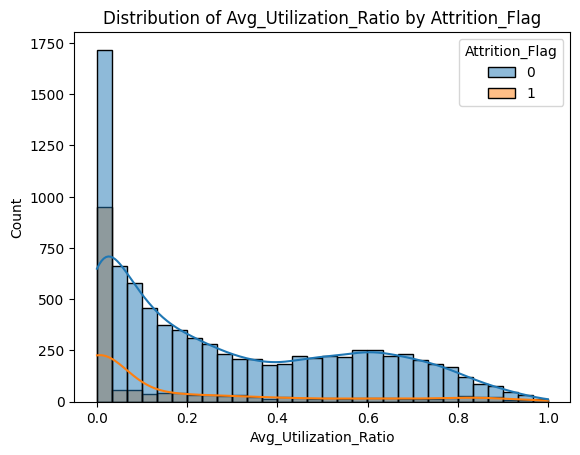

In [6]:

print("\n===== Numeric Feature Descriptive Statistics =====")
display(df[num_cols].describe())

key_numeric = [
    "Total_Relationship_Count",
    "Total_Revolving_Bal",
    "Total_Trans_Ct",
    "Total_Trans_Amt",
    "Months_Inactive_12_mon",
    "Contacts_Count_12_mon",
    "Total_Amt_Chng_Q4_Q1",
    "Total_Ct_Chng_Q4_Q1",
    "Credit_Limit",
    "Avg_Utilization_Ratio"
]

print("\n===== Distributions for Key Numeric Features =====")

for col in key_numeric:
    if col in df.columns:
        plt.figure()
        sns.histplot(data=df, x=col, hue="Attrition_Flag", kde=True, bins=30)
        plt.title(f"Distribution of {col} by Attrition_Flag")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.show()

Analýza kategorických premenných a súvislostí medzi "Attrition rates" a jednotlivými hodnotami týchto premenných potvrdzuje, že hodnota "Attrition rate" sa signifikantne líši medzi jednotlivými hodnotami jednotlivých kategorických atribútov.

Z uvedeného automaticky vyplýva, že tieto kategorické atribúty obsahujú zmysluplné prediktívne informácie, ktoré majú vplyv na klasifikáciu. Z uvedeného dôvodu budú všetky kategoriálne premenné zahrnuté s využitím one-hot encoding.



===== Categorical Feature Analysis (Churn Rate by Category) =====

Churn rate by Gender:


,Churn_Rate
Gender,
F,0.173572
M,0.146152


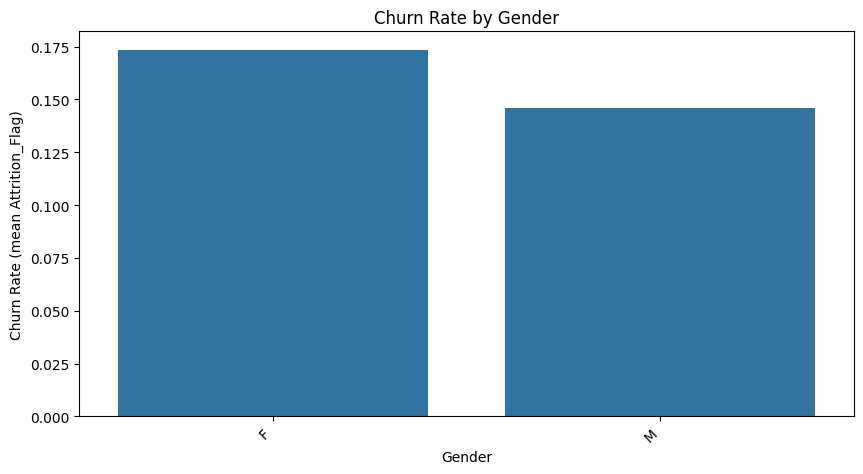


Churn rate by Education_Level:


,Churn_Rate
Education_Level,
Doctorate,0.210643
Post-Graduate,0.178295
Unknown,0.168532
Uneducated,0.159381
Graduate,0.155691
College,0.152024
High School,0.152012


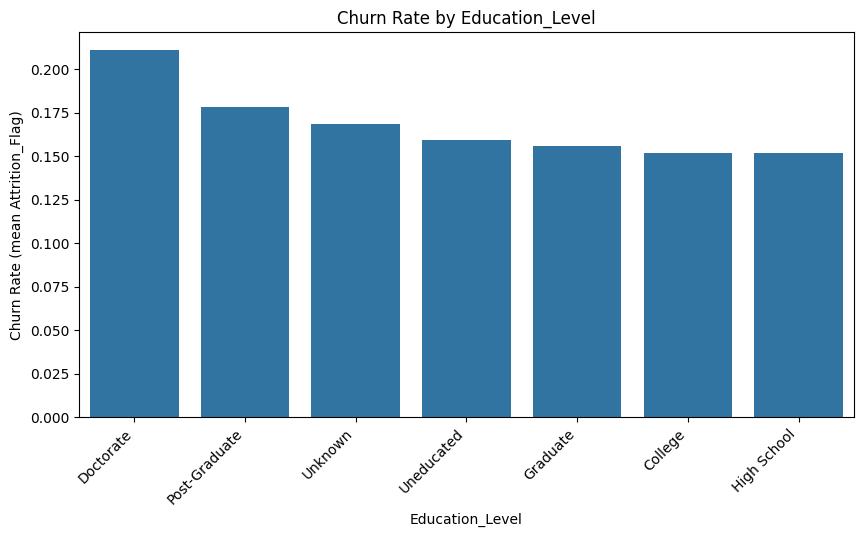


Churn rate by Marital_Status:


,Churn_Rate
Marital_Status,
Unknown,0.172230
Single,0.169414
Divorced,0.161765
Married,0.151269


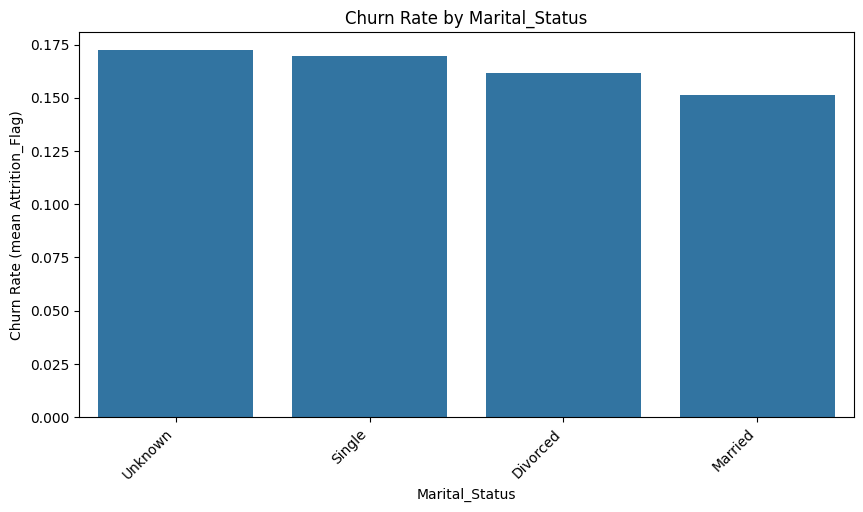


Churn rate by Income_Category:


,Churn_Rate
Income_Category,
$120K +,0.173315
Less than $40K,0.171862
Unknown,0.168165
$80K - $120K,0.157655
$40K - $60K,0.151397
$60K - $80K,0.134807


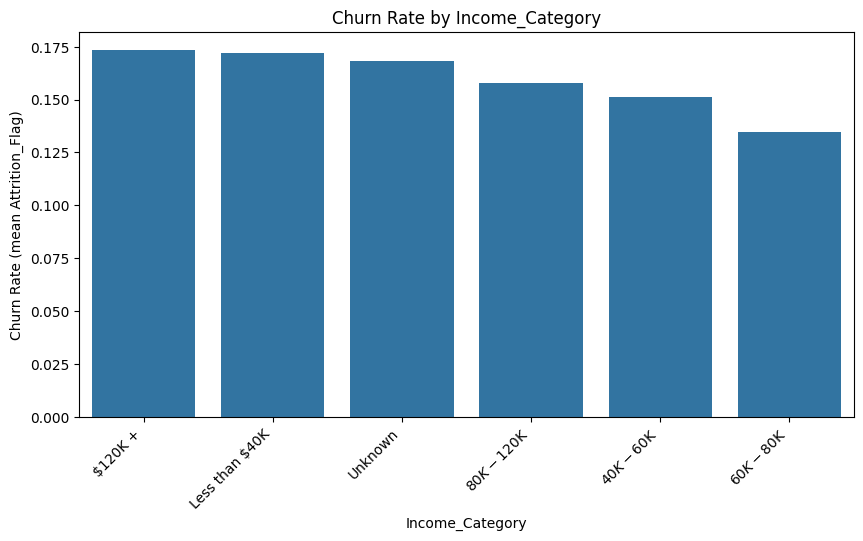


Churn rate by Card_Category:


,Churn_Rate
Card_Category,
Platinum,0.250000
Gold,0.181034
Blue,0.160979
Silver,0.147748


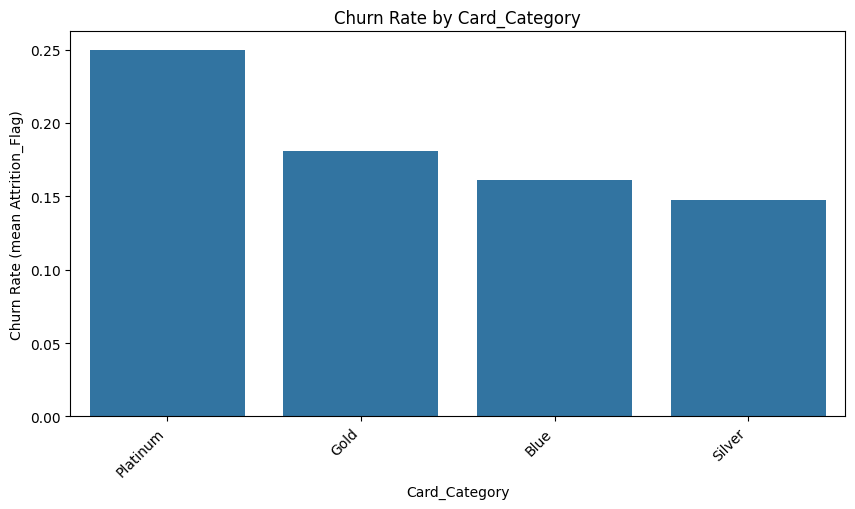

In [7]:
cat_to_analyze = ["Gender", "Education_Level", "Marital_Status", "Income_Category", "Card_Category"]


print("\n===== Categorical Feature Analysis (Churn Rate by Category) =====")

for col in cat_to_analyze:
    if col in df.columns:
        churn_rate = df.groupby(col)["Attrition_Flag"].mean().sort_values(ascending=False)
        print(f"\nChurn rate by {col}:")
        display(churn_rate.to_frame(name="Churn_Rate"))

        plt.figure(figsize=(10, 5))
        sns.barplot(x=churn_rate.index, y=churn_rate.values)
        plt.title(f"Churn Rate by {col}")
        plt.xlabel(col)
        plt.ylabel("Churn Rate (mean Attrition_Flag)")
        plt.xticks(rotation=45, ha="right")
        plt.show()

# **Preprocessing, voľba metriky a "base" 10-fold cross-validation (s default hodnotami hyper-parametrov)**
Vlastnú k-fold krížovú validáciu (cross-validation) v záujme jednoduchosti kódu a reprodukovateľnosti spájam s preprocessingom dát, s využitím "Pipeline" objektu. Vytváram tak kompletný a reprodukovateľný workflow predspracovania a vlastného vyhodnocovania modelu, ktorý je následne ako callable objekt použiteľný jednotne pre všetky algoritmy.


V rámci uvedeného ako prvý krok vytváram objekt "Preprocessor" typu ColumnTransformer, ktorý predstavuje jadro predspracovania v rámci "Pipeline". Pre numerické premenné používam transformáciu MinMaxScaler(), ktorá škáluje hodnoty do intervalu ⟨0, 1⟩.  Pre kategorické premenné používam OneHotEncoder, teda one-hot encoding, ktorý premieňa textové kategórie na binárne (0/1) indikátorové stĺpce.

Po definovaní "Preprocessing" vytváram samostatné pipeline objekty pre každý z vybraných klasifikačných algoritmov. Každý pipeline pozostáva z dvoch krokov: prvým krokom je preprocessing, kde sa aplikuje škálovanie numerických premenných a one-hot encoding kategórií, a druhým krokom je samotný klasifikačný model. Ako modely používam Decision Tree (DecisionTreeClassifier), k=NN (KNeighborsClassifier) a Naive Bayes (GaussianNB). V pôvodnej pracovnej verzii som namiesto Naive Bayes používal MLP, ktorý mal ale pomerne rozsiahle problémy s konvergenciou,takže som ho nahradil práve  algoritmom Naive Bayes.

V následnom kroku vytváram objekt typu StratifiedKFold s 10 "zložkami" (folds,n_splits=10). Voľba "stratified"  je odôvodnené skutočnosťou, že cieľový dataset Y (hodnoty Attrition_Flag) je pomerne výrazne nevyvážený (80% na 20%) a z uvedeného dôvodu je vhodné aby každá zložka (fold) obsahovala približne rovnaký podiel attrited zákazníkov.

Ako už bolo spomínané a odôvodnené vyššie, kľúčovou metrikou je "Recall", pričom vyhodnocujem aj "F1-score" (a v nadväznosti naň aj "Precision").

Následne spúšťam 10-násobnú stratifikovanú krížovú validáciu pomocou funkcie cross_validate pre každý pipeline. To znamená, že dataset je rozdelený na 10 častí, pričom v každej iterácii sa model trénuje na 9 častiach a testuje na zostávajúcej časti. Tento proces sa opakuje 10-krát, takže každý záznam sa presne raz použije ako testovací. Výsledkom je séria hodnôt recall, precision a F1-score pre každý fold.

V záverečnej časti vytváram sumárny prehľad výsledkov všetkých testovaných modelov.


In [8]:
#Create numeric and categorical column lists
numeric_features = X.select_dtypes(include=[np.number]).columns
categorical_features = X.select_dtypes(include=["object", "category"]).columns

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

#Creating preprocessor (scaling and one-hot encoding) for pipeline latter
preprocessor = ColumnTransformer(
    transformers=[
        ("num", MinMaxScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

#create pipelines, one for each selected algorithm: Decision Tree, k-nearestneighbors, Naive Bayes
pipe_tree = Pipeline([
    ("preprocess", preprocessor),
    ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))
])

pipe_knn = Pipeline([
    ("preprocess", preprocessor),
    ("model", KNeighborsClassifier())
])

pipe_nb = Pipeline([
    ("preprocess", preprocessor),
    ("model", GaussianNB())
])

#create stratified 10-fold object
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

#define metrics - I am using recall, f1 and precision as explained above
scoring = {
    "recall": "recall",
    "precision": "precision",
    "f1": "f1"
}

#execute 10-fold cross validation with each algorithm
results_tree = cross_validate(pipe_tree, X, Y, cv=cv, scoring=scoring)
results_knn = cross_validate(pipe_knn, X, Y, cv=cv, scoring=scoring)
results_nb = cross_validate(pipe_nb, X, Y, cv=cv, scoring=scoring)

#print results for base testing (with default hyperparameters)
summary = pd.DataFrame({
    "Model": ["Decision Tree", "k-NN", "Naive Bayes"],
    "Recall_mean": [
        results_tree["test_recall"].mean(),
        results_knn["test_recall"].mean(),
        results_nb["test_recall"].mean()
    ],
    "Recall_std": [
        results_tree["test_recall"].std(),
        results_knn["test_recall"].std(),
        results_nb["test_recall"].std()
    ],
    "Precision_mean": [
        results_tree["test_precision"].mean(),
        results_knn["test_precision"].mean(),
        results_nb["test_precision"].mean()
    ],
    "Precision_std": [
        results_tree["test_precision"].std(),
        results_knn["test_precision"].std(),
        results_nb["test_precision"].std()
    ],
    "F1_mean": [
        results_tree["test_f1"].mean(),
        results_knn["test_f1"].mean(),
        results_nb["test_f1"].mean()
    ],
    "F1_std": [
        results_tree["test_f1"].std(),
        results_knn["test_f1"].std(),
        results_nb["test_f1"].std()
    ],
})

summary


Numeric features:
Index(['Customer_Age', 'Dependent_count', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'],
      dtype='object')

Categorical features:
Index(['Gender', 'Education_Level', 'Marital_Status', 'Income_Category',
       'Card_Category'],
      dtype='object')


,Model,Recall_mean,Recall_std,Precision_mean,Precision_std,F1_mean,F1_std
0,Decision Tree,0.799031,0.035293,0.818259,0.028772,0.808317,0.029507
1,k-NN,0.262402,0.029145,0.657357,0.057984,0.374778,0.037917
2,Naive Bayes,0.598027,0.040118,0.632981,0.036183,0.614092,0.030068


# **Vyhodnotenie "base" CV**

Výsledky base CV jasne ukazujú výrazné rozdiely vo výkonnosti jednotlivých algoritmov pri predikcii odchodu zákazníkov. Keďže cieľová trieda „Attrited Customer" tvorí menšinu, kľúčovou metrikou je najmä Recall, teda schopnosť modelu zachytiť čo najväčší podiel skutočne odchádzajúcich zákazníkov.

Najlepšie výsledky dosahuje Decision Tree, ktorý má priemerný Recall približne 0,80 (0,799), čo znamená, že model dokáže správne identifikovať približne 80 % zákazníkov, ktorí v skutočnosti odídu. Zároveň má aj vysokú hodnotu Precision (0,818) a F1-score (0,808), čo naznačuje, že model nielen úspešne zachytáva „Attrited Customer", ale zároveň pri tom produkuje relatívne málo falošných poplachov (false positives). Štandardné odchýlky pri všetkých metrikách sú pomerne nízke, čo svedčí o stabilnom a konzistentnom výkone naprieč jednotlivými foldmi. Tento model je teda v baseline nastavení jednoznačne najvhodnejší pre danú úlohu.

Naive Bayes dosahuje stredne dobré výsledky. Jeho Recall je približne 0,60 (0,598), čo znamená, že zachytí približne 60 % „Attrited Customer". Precision (0,633) a F1-score (0,614) sú takisto nižšie ako pri Decision Tree, čo naznačuje slabšiu schopnosť odlíšiť „Attrited Customer" od neodchádzajúcich. Napriek tomu ide o relatívne stabilný model (nízka F1_std ≈ 0,030), ktorý je zároveň veľmi rýchly a jednoduchý. Z pohľadu praxe však pri Attrition predikcii môže byť Recall okolo 0,60 nedostatočný, pretože znamená, že približne 40 % odchádzajúcich zákazníkov zostane neodhalených.

Najslabšie dopadol k-NN, ktorý síce dosahuje pomerne vysokú Precision (0,657), ale extrémne nízky Recall (0,262). To znamená, že model síce v prípadoch, keď „Attrited Customer" predikuje, má relatívne dobrú „presnosť“ predikcie, avšak väčšinu „Attrited Customer" vôbec neodhalí – zachytí len približne 26 % odchádzajúcich zákazníkov. Takýto výsledok je z pohľadu Attrition predikcie veľmi problematický, pretože model produkuje veľké množstvo false negatives (neodhalené odchody), čo predstavuje najväčšie obchodné riziko. Nízky Recall sa dá vysvetliť tým, že k-NN je algoritmus založený na vzdialenosti, ktorý je citlivý na nevyváženosť tried a zároveň môže mať problémy v prostredí s vyššou dimenzionalitou po one-hot encodovaní kategórií. Výsledky naznačujú, že k-NN potrebuje výraznejšie ladenie hyperparametrov (najmä n_neighbors, weights a voľbu metriky), aby sa jeho schopnosť zachytiť Attrited customers zlepšila.

V nasledovnej časti (ladenie hyper-parametrov) sa preto sústredím predovšetkým na hľadanie optimálnej kombinácie hyper-parametrov predovšetkým pre túto metódu (s cieľom dosiahnuť výrazne lepšie výsledky, resp. s cieľom potvrdiť, že uvedená metóda je na tento dataset a cieľ nevhodná).

# **Ladenie hyper-parametrov**
Záverečná časť je zameraná na ladenie (tuning) hyperparametrov pre tri vybrané klasifikačné algoritmy: Decision Tree, k-NN a Naive Bayes. Cieľom je nájsť takú kombináciu nastavení modelov, ktorá maximalizuje zvolenú hodnotiacu metriku -  Recall.

Podobne ako v prípade base CV postup testovania jednotlivých kombinácií parametrov automatizujem vytvorením slovníkov jednotlivých kombinácií (tzv. param_grid) pre všetky testované algoritmy. Najväčší dôraz (a teda najviac testovaných kombinácií) som kládol na k-NN ako algoritmus s najhoršími výsledkami v základnom testovaní.

Pri Decision Tree testujem hĺbku stromu (max_depth), minimálny počet vzoriek v liste (min_samples_leaf) a tiež vplyv váženia tried (class_weight). Týmto spôsobom sa model skúša jednak v „nevyváženom“ nastavení (bez vyrovnávania tried), ako aj v nastavení "balanced", ktoré dáva väčšiu váhu minoritnej triede "Attrited customer". Celkovo sa tu testuje 12 kombinácií.

Pri Naive Bayes sa testuje parameter var_smoothing, ktorý slúži na numerickú stabilitu výpočtov (pridáva malé číslo k variancii). Tento model má veľmi málo hyperparametrov, preto je počet kombinácií menší (4 varianty).

Pri k-NN sa testujú tri kľúčové parametre: počet susedov (n_neighbors), spôsob váženia susedov (weights) a typ metriky vzdialenosti (metric). k-NN je algoritmus založený na vzdialenosti, preto sa predpokladá, že vhodným výberom týchto parametrov sa môže jeho výkon výraznejšie zlepšiť. Celkovo sa testuje 28 kombinácií.

Následne sa pre každý algoritmus vytvorí samostatný objekt GridSearchCV, ktorý vezme pripravené pipelines (pipe_tree, pipe_knn, pipe_nb), prejde všetky kombinácie hyperparametrov definované v param_grid_*, vyhodnotí ich pomocou stratifikovanej 10-násobnej krížovej validácie (cv=cv), použije metriku scoring="recall" na výber najlepšej konfigurácie a pri refit=True nakoniec automaticky natrénuje najlepší model na celom datasete.

V závere sú vypísané výsledky pre všetky testované kombinácie pre všetky algoritmy a tiež najlepšia kombinácia parametrov a jej zodpovedajúci najlepší výsledok pre každý algoritmus.

In [9]:
#Hyperparameter tunning
#WARNING: DUE TO 10-fold CV and relatively high number of tested combinations, it will take aproximatelly 1.5 minute to compute this cell

#combinations of tested hyper-parameters for decision tree (12 variants)
param_grid_tree = {
    "model__max_depth": [5, 7, None],
    "model__min_samples_leaf": [1, 5],
    "model__class_weight": [None, "balanced"]
}

#combinations of tested hyper-parameters for Naive Bayes (4 variants)
param_grid_nb = {
    "model__var_smoothing": [1e-12, 1e-10, 1e-9, 1e-8]
}

#combinations of tested hyper-parameters for k-NN (28 variants)
param_grid_knn = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 15, 21],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"]
}

#gridSearchCV object for decision tree
grid_tree = GridSearchCV(
    estimator=pipe_tree,
    param_grid=param_grid_tree,
    cv=cv,
    scoring="recall",
    n_jobs=-1,
    refit=True
)

#gridSearchCV object for k-NN
grid_knn = GridSearchCV(
    estimator=pipe_knn,
    param_grid=param_grid_knn,
    cv=cv,
    scoring="recall",
    n_jobs=-1,
    refit=True
)

#gridSearchCV object for Naive Bayes
grid_nb = GridSearchCV(
    estimator=pipe_nb,
    param_grid=param_grid_nb,
    cv=cv,
    scoring="recall",
    n_jobs=-1,
    refit=True
)


# Run Decision Tree with all hyper-parameters variants
grid_tree.fit(X, Y)

#Print results for Decision tree - all combinations
print("\n" + "="*60)
print("DECISION TREE — ALL TESTED HYPERPARAMETER COMBINATIONS")
print("="*60)

tree_results_df = pd.DataFrame(grid_tree.cv_results_)
tree_results_df = tree_results_df[["rank_test_score", "mean_test_score", "params"]]
tree_results_df = tree_results_df.sort_values("rank_test_score")

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

display(tree_results_df)

print("\nBEST DECISION TREE CONFIGURATION:")
print("Best params:", grid_tree.best_params_)
print(f"Best mean CV Recall: {grid_tree.best_score_:.4f}")


# Run k-NN with all hyper-parameters variants
grid_knn.fit(X, Y)

#Print results for k-NN - all combinations
print("\n" + "="*60)
print("k-NN — ALL TESTED HYPERPARAMETER COMBINATIONS")
print("="*60)

knn_results_df = pd.DataFrame(grid_knn.cv_results_)
knn_results_df = knn_results_df[["rank_test_score", "mean_test_score", "params"]]
knn_results_df = knn_results_df.sort_values("rank_test_score")

display(knn_results_df)

print("\nBEST k-NN CONFIGURATION:")
print("Best params:", grid_knn.best_params_)
print(f"Best mean CV Recall: {grid_knn.best_score_:.4f}")


# Run Naive Bayes with all hyper-parameters variants
grid_nb.fit(X, Y)

#Print results for Naive Bayes - all combinations
print("\n" + "="*60)
print("NAIVE BAYES — ALL TESTED HYPERPARAMETER COMBINATIONS")
print("="*60)

nb_results_df = pd.DataFrame(grid_nb.cv_results_)
nb_results_df = nb_results_df[["rank_test_score", "mean_test_score", "params"]]
nb_results_df = nb_results_df.sort_values("rank_test_score")

display(nb_results_df)

print("\nBEST NAIVE BAYES CONFIGURATION:")
print("Best params:", grid_nb.best_params_)
print(f"Best mean CV Recall: {grid_nb.best_score_:.4f}")



#Print summary results - just best combinations
print("\n" + "="*60)
print("SUMMARY RESULTS")
print("="*60)

print("===== SUMMARY - BEST DECISION TREE =====")
print("Best params:", grid_tree.best_params_)
print("Best CV Recall:", grid_tree.best_score_)

print("\n===== SUMMARY - BEST k-NN =====")
print("Best params:", grid_knn.best_params_)
print("Best CV Recall:", grid_knn.best_score_)

print("\n===== SUMMARY - BEST NAIVE BAYES =====")
print("Best params:", grid_nb.best_params_)
print("Best CV Recall:", grid_nb.best_score_)

tuning_summary = pd.DataFrame({
    "Model": ["Decision Tree", "k-NN", "Naive Bayes"],
    "Best Recall (CV mean)": [
        grid_tree.best_score_,
        grid_knn.best_score_,
        grid_nb.best_score_
    ],
    "Best Params": [
        grid_tree.best_params_,
        grid_knn.best_params_,
        grid_nb.best_params_
    ]
})

tuning_summary


DECISION TREE — ALL TESTED HYPERPARAMETER COMBINATIONS


,rank_test_score,mean_test_score,params
9,1,0.910861,"{'model__class_weight': 'balanced', 'model__max_depth': 7, 'model__min_samples_leaf': 5}"
8,2,0.903492,"{'model__class_weight': 'balanced', 'model__max_depth': 7, 'model__min_samples_leaf': 1}"
7,3,0.898599,"{'model__class_weight': 'balanced', 'model__max_depth': 5, 'model__min_samples_leaf': 5}"
6,4,0.897985,"{'model__class_weight': 'balanced', 'model__max_depth': 5, 'model__min_samples_leaf': 1}"
11,5,0.877043,"{'model__class_weight': 'balanced', 'model__max_depth': None, 'model__min_samples_leaf': 5}"
3,6,0.810710,"{'model__class_weight': None, 'model__max_depth': 7, 'model__min_samples_leaf': 5}"
2,7,0.804579,"{'model__class_weight': None, 'model__max_depth': 7, 'model__min_samples_leaf': 1}"
4,8,0.799031,"{'model__class_weight': None, 'model__max_depth': None, 'model__min_samples_leaf': 1}"
5,9,0.796561,"{'model__class_weight': None, 'model__max_depth': None, 'model__min_samples_leaf': 5}"
1,10,0.795304,"{'model__class_weight': None, 'model__max_depth': 5, 'model__min_samples_leaf': 5}"



BEST DECISION TREE CONFIGURATION:
Best params: {'model__class_weight': 'balanced', 'model__max_depth': 7, 'model__min_samples_leaf': 5}
Best mean CV Recall: 0.9109

k-NN — ALL TESTED HYPERPARAMETER COMBINATIONS


,rank_test_score,mean_test_score,params
15,1,0.354594,"{'model__metric': 'manhattan', 'model__n_neighbors': 3, 'model__weights': 'distance'}"
14,2,0.347838,"{'model__metric': 'manhattan', 'model__n_neighbors': 3, 'model__weights': 'uniform'}"
17,3,0.322033,"{'model__metric': 'manhattan', 'model__n_neighbors': 5, 'model__weights': 'distance'}"
1,4,0.310960,"{'model__metric': 'euclidean', 'model__n_neighbors': 3, 'model__weights': 'distance'}"
16,5,0.310357,"{'model__metric': 'manhattan', 'model__n_neighbors': 5, 'model__weights': 'uniform'}"
0,6,0.301746,"{'model__metric': 'euclidean', 'model__n_neighbors': 3, 'model__weights': 'uniform'}"
19,7,0.291297,"{'model__metric': 'manhattan', 'model__n_neighbors': 7, 'model__weights': 'distance'}"
18,8,0.277164,"{'model__metric': 'manhattan', 'model__n_neighbors': 7, 'model__weights': 'uniform'}"
3,9,0.268549,"{'model__metric': 'euclidean', 'model__n_neighbors': 5, 'model__weights': 'distance'}"
21,10,0.267341,"{'model__metric': 'manhattan', 'model__n_neighbors': 9, 'model__weights': 'distance'}"



BEST k-NN CONFIGURATION:
Best params: {'model__metric': 'manhattan', 'model__n_neighbors': 3, 'model__weights': 'distance'}
Best mean CV Recall: 0.3546

NAIVE BAYES — ALL TESTED HYPERPARAMETER COMBINATIONS


,rank_test_score,mean_test_score,params
0,1,0.598027,{'model__var_smoothing': 1e-12}
1,1,0.598027,{'model__var_smoothing': 1e-10}
2,1,0.598027,{'model__var_smoothing': 1e-09}
3,1,0.598027,{'model__var_smoothing': 1e-08}



BEST NAIVE BAYES CONFIGURATION:
Best params: {'model__var_smoothing': 1e-12}
Best mean CV Recall: 0.5980

SUMMARY RESULTS
===== SUMMARY - BEST DECISION TREE =====
Best params: {'model__class_weight': 'balanced', 'model__max_depth': 7, 'model__min_samples_leaf': 5}
Best CV Recall: 0.9108611679163827

===== SUMMARY - BEST k-NN =====
Best params: {'model__metric': 'manhattan', 'model__n_neighbors': 3, 'model__weights': 'distance'}
Best CV Recall: 0.3545936529576611

===== SUMMARY - BEST NAIVE BAYES =====
Best params: {'model__var_smoothing': 1e-12}
Best CV Recall: 0.5980269635688857


,Model,Best Recall (CV mean),Best Params
0,Decision Tree,0.910861,"{'model__class_weight': 'balanced', 'model__max_depth': 7, 'model__min_samples_leaf': 5}"
1,k-NN,0.354594,"{'model__metric': 'manhattan', 'model__n_neighbors': 3, 'model__weights': 'distance'}"
2,Naive Bayes,0.598027,{'model__var_smoothing': 1e-12}


# **Vyhodnotenie výsledkov a záverečné zhrnutie**
## **Decision tree**
Decision Tree dosiahol po ladení hyperparametrov ešte o niečo lepší výsledok oproti base kombinácii parametrov. Najlepšia konfigurácia má Recall = 0.9109.
Ide o nasledovnú kombináciu parametrov:

class_weight = "balanced"

max_depth = 7

min_samples_leaf = 5

Z porovnania  výsledkov pre jednotlivé kombinácie je zrejmé, že najväčší prínos má jednoznačne nastavenie class_weight="balanced", ktoré zvýhodňuje minoritnú triedu a tým zvyšuje schopnosť modelu zachytiť attrition.


## **Naive Bayes**
Naive Bayes dosiahol aj po tunningu hyper-parametrov rovnakú hodnotu ako pri baseline nastavení, všetky testované varianty priniesli rovnakú hodnotu testovanej metriky (Recall = 0.5980).

To znamená, že parameter var_smoothing v tomto datasete nemá praktický vplyv na schopnosť modelu identifikovať attrition. Výkonnosť Naive Bayes tak ostáva na úrovni baseline (Recall ≈ 0.598), teda stredná výkonnosť – lepšia než k-NN, ale výrazne horšia než Decision Tree.


## **k-NN**
V prípade k-NN nebol dostatočne dobrý výsledok dosiahnutý pri žiadnej z testovaných kombinácií. Najlepšia konfigurácia dosahuje Recall = 0.3546.

Ide o kombináciu":

metric = "manhattan"

n_neighbors = 3

weights = "distance"

V porovnaní s baseline nastavením (Recall ≈ 0.262) došlo síce k zlepšeniu, ale stále ide o veľmi nízku hodnotu. To znamená, že aj po tuningu k-NN zachytí len približne 35 % Attrited customers, čo je z praktického pohľadu pre túto predikciu nevyhovujúce.

Aj napriek neuspokojivým výsledkom priebežné výsledky zároveň  ukazujú nasledovné trendy:

metrika manhattan funguje lepšie než euclidean, pravdepodobne vďaka tomu, že po one-hot encodingu vzniká vysokodimenzionálny priestor, kde Manhattan vzdialenosť často poskytuje stabilnejšie porovnanie,

najlepšie výsledky vychádzajú pri veľmi nízkom počte susedov (k=3),

váženie susedov podľa vzdialenosti (distance) zlepšuje Recall oproti uniformnému hlasovaniu.

Napriek tomu k-NN zrejme trpí kombináciou nevyváženosti tried a vysokej dimenzionality dát po kódovaní kategórií.





# **Záverečné zhrnutie**
Najlepším algoritmom zo všetkých algoritmov testovaných v tomto projekte je Decision Tree, ktorý po ladení hyperparametrov dosiahol Recall ≈ 0.91, čo znamená, že zachytí viac než 90 % Attrited customers. Táto hodnota je výrazne vyššia než pri ostatných algoritmoch a zároveň je najviac v súlade s cieľom projektu (minimalizovať false negatives).

Najväčší prínos pri Decision Tree prinieslo nastavenie class_weight="balanced", ktoré zlepšilo schopnosť modelu identifikovať minoritnú triedu Attrited customer. Optimálnou sa ukázala kombinácia strednej hĺbky stromu (max_depth=7) a obmedzenia listov (min_samples_leaf=5), ktorá znižuje riziko overfitting.

k-NN aj po tuningu zostáva nevhodný pre Attrited customers predikciu v tomto datasete, keďže jeho Recall sa zvýšil len na ≈ 0.35. To znamená, že väčšinu Attrited customers nedokáže zachytiť, čo je v praxi neprijateľné. Výsledky naznačujú, že k-NN je silne negatívne ovplyvnený nevyváženosťou tried a vysokou dimenzionalitou dát po one-hot encodingu.

Naive Bayes dosahuje stabilný, ale len stredný výkon (Recall ≈ 0.60). Tuning parametra var_smoothing nemal žiadny efekt, čo potvrdzuje, že tento model má limitovanú schopnosť zlepšenia cez hyperparametre. Napriek tomu môže slúžiť ako rýchly referenčný baseline model.

Z pohľadu cieľov projektu (predikcia odchodu zákazníkov a minimalizácia false negatives) je teda finálnym odporúčaním použiť Decision Tree s naladenými hyperparametrami, pretože poskytuje najvyšší Recall a zároveň pravdepodobne aj dobrú hodnotu F1-score v porovnaní s ostatnými modelmi.